<a href="https://colab.research.google.com/github/douniaedben/Data-Analysis/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install fuzzywuzzy


In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
from fuzzywuzzy import fuzz, process
from itertools import combinations

/usr/local/lib/python3.10/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [ ]:
dirty_data = pd.read_csv('/content/drive/MyDrive/ecommerce-dataset.csv', encoding='latin1')
dirty_data.sample(100)


,Transaction ID,Customer Name,Product Category,Sales Amount,Quantity,Customer Satisfaction Rating
8318,3878bda1-2b7d-404a-b63e-0f3b085b78f2,William Grant,CLOTHING,372.82,44.0,4.8
6580,1e17b04c-e1ec-42fd-9ede-82adbcd8a86c,aaron white,Clothing,184.97,29.0,2.6
12617,4b1740ab-c5a8-4931-a4f3-f789f8a70693,dr. lisa lopez md,Electronics,936.14,17.0,1.9
4883,2f67142d-fae1-4f5c-93e9-fa0b3b07f0e9,Caitlyn Wood,clothing,583.45,5.0,3.5
4337,bb95db3c-ffd2-437c-afba-82bd1e795732,peggy bell,ELECTRONICS,643.93,29.0,4.9
...,...,...,...,...,...,...
12788,f240de81-26fd-402e-b490-87ad7f0ffe79,Karen Hayes,Electronics,234.22,42.0,2.2
8503,4dcdf5f1-7a55-484c-b729-2f981ade6265,Maria Weaver,Electronics,784.97,34.0,4.5
4548,4e6e9369-e9de-4c03-bbcb-2f62f33b7080,Christopher Dickerson,clothing,587.02,18.0,2.1
5471,7727a53d-9565-447f-8a77-6f6d0ee0d3d3,paul gordon,ELECTRONICS,592.46,48.0,4.5


In [ ]:
print("the dataset informations: ")
dirty_data.info()
dirty_data.shape


the dataset informations: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13828 entries, 0 to 13827
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction ID                13820 non-null  object 
 1   Customer Name                 13819 non-null  object 
 2   Product Category              13819 non-null  object 
 3   Sales Amount                  13819 non-null  object 
 4   Quantity                      13819 non-null  float64
 5   Customer Satisfaction Rating  13819 non-null  float64
dtypes: float64(2), object(4)
memory usage: 648.3+ KB


(13828, 6)

In [ ]:
dirty_data.describe()

,Quantity,Customer Satisfaction Rating
count,13819.000000,13819.000000
mean,25.761343,3.008742
std,14.379764,1.174095
min,1.000000,1.000000
25%,14.000000,2.000000
50%,26.000000,3.000000
75%,38.000000,4.000000
max,50.000000,21.400000


In [ ]:
dirty_data.isnull().sum()

,0
Transaction ID,8
Customer Name,9
Product Category,9
Sales Amount,9
Quantity,9
Customer Satisfaction Rating,9


In [ ]:
numerical_cols = dirty_data.select_dtypes(include=['float64', 'int64']).columns
dirty_data[numerical_cols].describe()

,Quantity,Customer Satisfaction Rating
count,13819.000000,13819.000000
mean,25.761343,3.008742
std,14.379764,1.174095
min,1.000000,1.000000
25%,14.000000,2.000000
50%,26.000000,3.000000
75%,38.000000,4.000000
max,50.000000,21.400000


In [ ]:
exctdup=dirty_data.duplicated()
totaldup=exctdup.sum()
print(totaldup)
dirty_data[exctdup]



2296


,Transaction ID,Customer Name,Product Category,Sales Amount,Quantity,Customer Satisfaction Rating
12,31fb41cb-0cb1-4778-bab0-7354424f6cb7,Victoria Santos,CLOTHING,864.73,47.0,3.1
18,bf23270b-8fcc-48c8-b350-20d983b41672,Rebecca Lucero,CLOTHING,128.19,50.0,3.3
25,6e9199c9-7aff-4367-a342-cef76a0ee253,CHRISTIE NORTON,ELECTRONICS,691.19,15.0,2.8
29,58d3cb0c-73a5-4641-bb8e-608b3199fce5,Kyle Morgan,Electronics,192.08,9.0,4.0
48,7f9bc4c7-daae-462d-80a1-29469718966b,JOEL WISE,clothing,912.66,8.0,3.9
...,...,...,...,...,...,...
13796,cfdc5a47-428b-4e72-a730-cd51cc697bd5,Gregory Burns,electronics,219.53,34.0,3.9
13799,10c8e6cf-c60f-4f8b-9835-e2a151e773c6,JOHN MEDINA,electronics,426.99,36.0,3.6
13803,383be588-4121-4f95-9f38-14e4365a62f9,christopher gordon dvm,electronics,857.58,45.0,3.9
13818,161d8dff-912c-4f14-9d6e-d3891bbd75df,Katrina Wilson,CLOTHING,775.41,14.0,3.1


In [ ]:
#Match customer names against a list
customer_names = dirty_data['Customer Name'].unique()
print(customer_names)
dirty_data['Customer Name'] = dirty_data['Customer Name'].str.lower().str.strip()
dirty_data['Product Category'] = dirty_data['Product Category'].str.lower().str.strip()
print(dirty_data[['Customer Name', 'Product Category']].head())

duplicate_rows = dirty_data[dirty_data.duplicated()]
print(duplicate_rows)





['Pam Snyder ' 'NATALIE HOBBS' 'Elizabeth Roberts ' ... 'alice travis'
 'timothy gilbert' 'CHARLES VASQUEZ']
       Customer Name Product Category
0         pam snyder         clothing
1      natalie hobbs      electronics
2  elizabeth roberts      electronics
3        jon cordova         clothing
4        kelly smith      electronics
                             Transaction ID           Customer Name  \
12     31fb41cb-0cb1-4778-bab0-7354424f6cb7         victoria santos   
18     bf23270b-8fcc-48c8-b350-20d983b41672          rebecca lucero   
20     f7341bff-2bca-4fcf-81e8-bd6a2b117bbe           mary crawford   
25     6e9199c9-7aff-4367-a342-cef76a0ee253         christie norton   
29     58d3cb0c-73a5-4641-bb8e-608b3199fce5             kyle morgan   
...                                     ...                     ...   
13796  cfdc5a47-428b-4e72-a730-cd51cc697bd5           gregory burns   
13799  10c8e6cf-c60f-4f8b-9835-e2a151e773c6             john medina   
13803  383be588-4121-4f9

# **Activity1:**

1- (13828, 6)

dtypes: float64(2), object(4)

2- yes they are:
Data Types: Sales Amount is stored as aN object type but should be numeric for analysis. INCONSISTENT CAPITALIZATIONS.

3-Numerical Column That Needs Scaling the Most:
Columns with large differences in their minimum and maximum values or high standard deviation will likely benefit the most from scaling.

*. Quantity :

Range: 1 to 50

Mean: 25.76

Standard Deviation: 14.38

*Customer Satisfaction Rating

Range: 1 to 21.4

Mean: 3.01

Standard Deviation: 1.17

# Activity02:
1- 2298 duplicates includes( Near-duplicates  ). ,16.56%
After removing duplicates:(11530, 6)

2-

*Data entry errors: -Typographical errors -inconsistent date formats - Human errors: Manual data entry might lead to duplicate entries.

*Errors in data collection systems,

3-  How does removing duplicates improve the accuracy and reliability of your analysis? ⁉
*Removing duplicates makes the data more accurate and efficient to work with. It helps ensure that analysis and models are based on reliable, non-redundant data, which leads to better decision-making and insights.







In [ ]:
cleaned_Data = dirty_data.drop_duplicates()
print(f"Removed {exctdup} exact duplicates.")
cleaned_Data.shape
#cleaned_Data.to_csv('cleaned_data.csv', index=False)

Removed 0        False
1        False
2        False
3        False
4        False
         ...  
13823     True
13824    False
13825    False
13826    False
13827    False
Length: 13828, dtype: bool exact duplicates.


(11530, 6)

# Activity03:
**How Did Fuzzy Matching Help Identify Duplicates?**

-> Fuzzy matching identifies duplicates that exact matching cannot by detecting similarities between strings even if they are not identical

**What Threshold Value Worked Best and Why?**

-> A **threshold of 85%** is often effective because:

*It balances sensitivity and precision.
*It captures true near-duplicates

e.g: typos or minor formatting issues while excluding unrelated entries.

**When Is Fuzzy Matching Most Useful?**

->Fuzzy matching is most useful for:

**User-generated content:**

Names: Handling typos or alternate spellings.

Addresses: Accounting for abbreviations and formatting differences (e.g., "St." vs. "Street").

**E-commerce datasets:**

Product names or categories with inconsistent entries (e.g., "Smartphone" vs. "Smart phone").

**Data cleaning:**
Detecting duplicates when merging datasets.

In [ ]:
#lowercase, no extra spaces:
cleaned_names =dirty_data['Customer Name'] = dirty_data['Customer Name'].str.lower().str.strip()
customer_names = dirty_data['Customer Name'].dropna().unique()
print(customer_names)

#Using fuzz.ratio() to compare two specific names
name1 = "john smith"
name2 = "jon smith"
similarity_score = fuzz.ratio(name1, name2)
matchess= process.extract(name1, customer_names, scorer=fuzz.ratio, limit=5)
print(matchess)
print(f"Similarity between '{name1}' and '{name2}': {similarity_score}")

                    ##############


similarity_threshold = 85
similar_pairs = []

# Trier les noms par longueur pour limiter les comparaisons
sorted_names = sorted(customer_names, key=len)
similar_pairs = []
for i, name1 in enumerate(sorted_names):
    for name2 in sorted_names[i+1:]:
        if abs(len(name1) - len(name2)) > 3:  # Filtrer par différence de longueur
            break
        similarity_score = fuzz.ratio(name1, name2)
        if similarity_score > similarity_threshold:
            similar_pairs.append((name1, name2, similarity_score))

# Affichage:

print("Paires similaires trouvées :")
for pair in similar_pairs:
    print(pair)










['pam snyder' 'natalie hobbs' 'elizabeth roberts' ... 'alice travis'
 'timothy gilbert' 'charles vasquez']
[('john smith', 100), ('joan smith', 90), ('jason smith', 86), ('joy smith', 84), ('jonathan smith', 83)]
Similarity between 'john smith' and 'jon smith': 95


KeyboardInterrupt: 

In [ ]:
data = dirty_data.drop_duplicates(subset='Customer Name')

# Replace NaN values with an empty string
dirty_data['Customer Name'] = dirty_data['Customer Name'].fillna('')

# Replace near-duplicates with standardized name
standardized_name = 'john smith'

# update  Customer Name
dirty_data.loc[dirty_data['Customer Name'].str.contains('john smith|jon smith', case=False), 'Customer Name'] = standardized_name

# Verify the changes
print(dirty_data[['Customer Name']].head())


       Customer Name
0         pam snyder
1      natalie hobbs
2  elizabeth roberts
3        jon cordova
4        kelly smith


# Note:
**loc:** Updates only the rows where the condition is True, replacing the value with 'john smith'

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


In [ ]:


# Convert 'Sales Amount' and 'Quantity' to numeric, forcing errors to NaN
dirty_data['Sales Amount'] = pd.to_numeric(dirty_data['Sales Amount'], errors='coerce')
dirty_data['Quantity'] = pd.to_numeric(dirty_data['Quantity'], errors='coerce')

#any NA value!!!!
print(dirty_data[['Sales Amount', 'Quantity']].isna().sum())

#  drop rows with NaN values
dirty_data.dropna(subset=['Sales Amount', 'Quantity'], inplace=True)





Sales Amount    10
Quantity         9
dtype: int64


In [ ]:

import seaborn as sns
#cleaning:

dirty_data['Sales Amount'] = dirty_data['Sales Amount'].replace({'\$': '', ',': '', '\*': ''}, regex=True)
dirty_data['Quantity'] = dirty_data['Quantity'].replace({'\$': '', ',': '', '\*': ''}, regex=True)

# Normalization
scaler_minmax = MinMaxScaler()
dirty_data[['Sales Amount', 'Quantity']] = scaler_minmax.fit_transform(dirty_data[['Sales Amount', 'Quantity']])

print("Normalized 'Sales Amount' and 'Quantity' Columns:")
print("Min-Max Scaled Sales Amount:", dirty_data['Sales Amount'].min(), dirty_data['Sales Amount'].max())
print("Min-Max Scaled Quantity:", dirty_data['Quantity'].min(), dirty_data['Quantity'].max())

# Standardization
scaler_standard = StandardScaler()
dirty_data['Customer Satisfaction Rating'] = scaler_standard.fit_transform(dirty_data[['Customer Satisfaction Rating']])

print("\nStandardized 'Customer Satisfaction Rating' Column:")
print(f"Mean: {dirty_data['Customer Satisfaction Rating'].mean()}, Std: {dirty_data['Customer Satisfaction Rating'].std()}")


Normalized 'Sales Amount' and 'Quantity' Columns:
Min-Max Scaled Sales Amount: 0.0 0.9999999999999999
Min-Max Scaled Quantity: 0.0 1.0

Standardized 'Customer Satisfaction Rating' Column:
Mean: -1.3369598443886674e-16, Std: 1.0000361866507592


->**Normalization**:

**Effect:**

-The minimum value becomes 0, and the maximum value becomes 1.

-All other values are scaled proportionally within this range.


->**Standardization**:

**Effect:**

-Outliers become less influential because they are scaled relative to the standard deviation.

-The shape of the distribution remains unchanged (e.g., skewness), but its scale shifts.

->For distance-based algorithms like k-means clustering, Normalization is the best choice because it prevents features with larger ranges (like Sales Amount) from dominating the calculations.





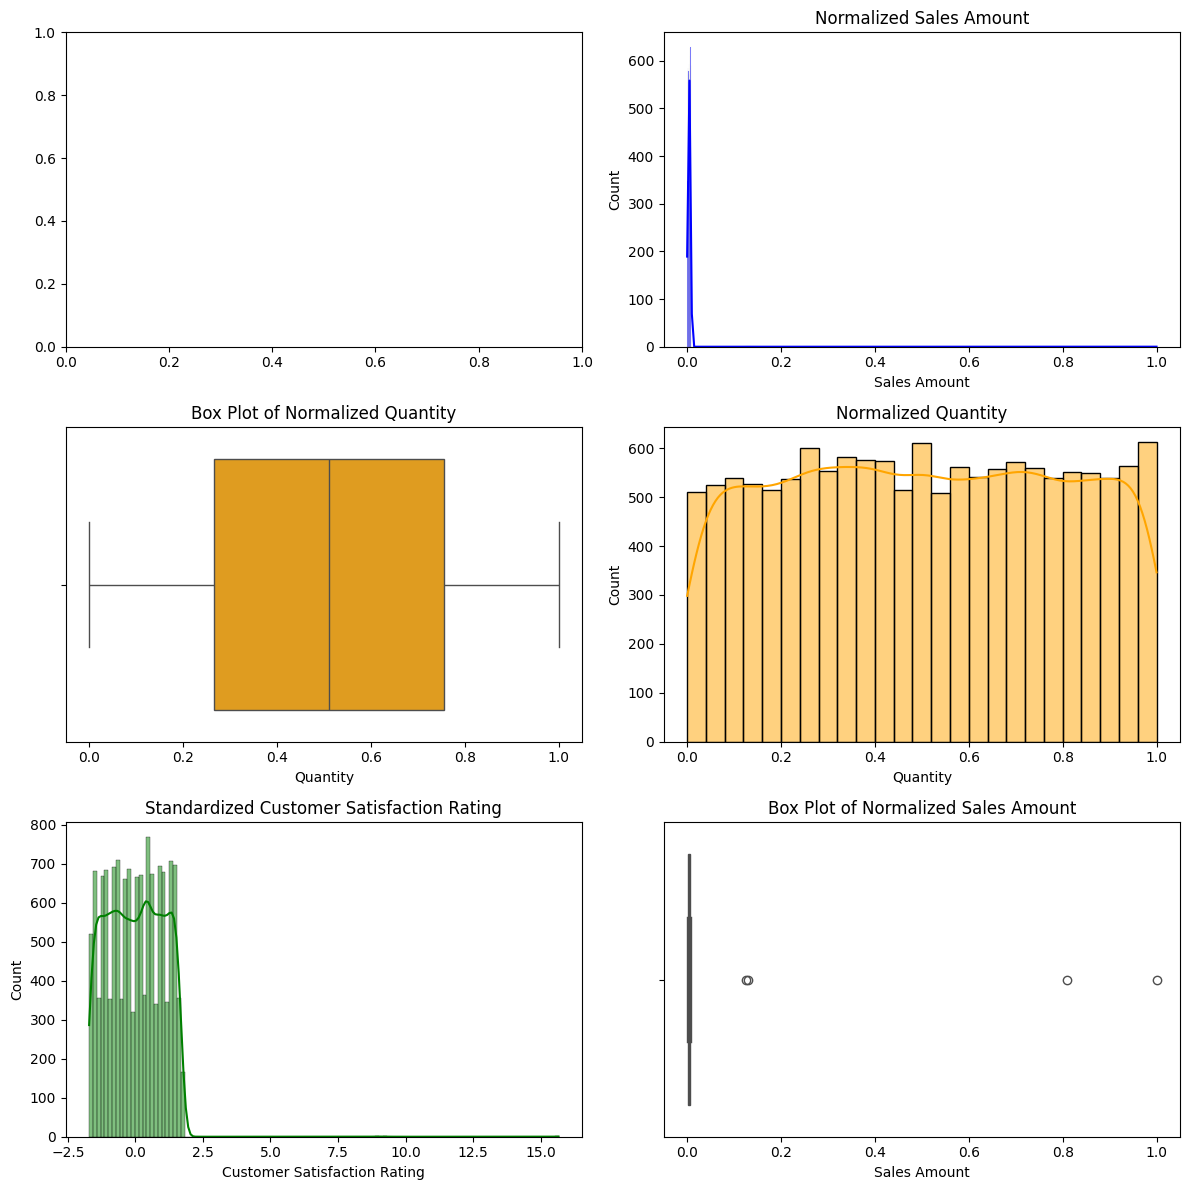

In [ ]:

# Visualization:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

#normalization:
sns.histplot(dirty_data['Sales Amount'], kde=True, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('Normalized Sales Amount')

sns.histplot(dirty_data['Quantity'], kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Normalized Quantity')

#standarization:
sns.histplot(dirty_data['Customer Satisfaction Rating'], kde=True, ax=axes[2, 0], color='green')
axes[2, 0].set_title('Standardized Customer Satisfaction Rating')

 #boxplot for normalization:
sns.boxplot(x=dirty_data['Sales Amount'], ax=axes[2, 1], color='blue')
axes[2, 1].set_title('Box Plot of Normalized Sales Amount')

sns.boxplot(x=dirty_data['Quantity'], ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Box Plot of Normalized Quantity')

plt.tight_layout()
plt.show()


In [ ]:
#to the CSV
dirty_data.to_csv('/content/drive/MyDrive/NEWecommerce-dataset.csv', index=False, encoding='latin1')